<a href="https://colab.research.google.com/github/Sheriff414/my_deeplearning_model/blob/master/thesis_model_build.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip3 install einops

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.8 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.utils.prune as prune
from einops.layers.torch import Reduce

In [ ]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

batch_size=4

# dataset has PILImage images of range [0, 1].
# We transform them to Tensors of normalized range [-1, 1]
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# CIFAR10: 60000 32x32 color images in 10 classes, with 6000 images per class
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                          shuffle=True)

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                         shuffle=False)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170498071/170498071 [00:12<00:00, 13118345.60it/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


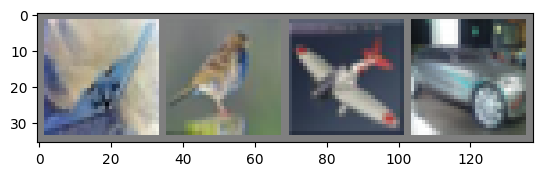

In [ ]:
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))


In [ ]:
# Hyper-parameters
num_epochs = 20
learning_rate = 0.001

#Teacher model
model=torchvision.models.resnet18(pretrained=True)
num_ftrs=model.fc.in_features
model.fc=nn.Linear(num_ftrs, 10)
bmodel = model.to(device)
# print(bmodel)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(bmodel.parameters(), lr=learning_rate)
n_total_steps = len(train_loader)

#Student model1
s1model=torchvision.models.resnet18(pretrained=True)
num_ftrs=s1model.fc.in_features
s1model.fc=nn.Linear(num_ftrs, 10)
s1model = s1model.to(device)
# print(bmodel)
criterion1 = nn.CrossEntropyLoss()
optimizer1 = torch.optim.SGD(s1model.parameters(), lr=learning_rate)
n_total_steps = len(train_loader)

#Student model2
s2model=torchvision.models.resnet18(pretrained=True)
num_ftrs=s2model.fc.in_features
s2model.fc=nn.Linear(num_ftrs, 10)
s2model = s2model.to(device)
# print(bmodel)
criterion2 = nn.CrossEntropyLoss()
optimizer2 = torch.optim.SGD(s2model.parameters(), lr=learning_rate)
n_total_steps = len(train_loader)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 230MB/s]


In [ ]:
def train_model(train_loader, optimizer, model, criterion, num_epochs, model_name):
    for epoch in range(num_epochs):
        for i, (images, labels) in enumerate(train_loader):
            # origin shape: [4, 3, 32, 32] = 4, 3, 1024
            # input_layer: 3 input channels, 6 output channels, 5 kernel size
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if (i+1) % 2000 == 0:
                print (f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{n_total_steps}], Loss: {loss.item():.4f}')

    print('Finished Training')
    PATH = './'+ model_name
    torch.save(model.state_dict(), PATH)


    # TESTING
    print("Running test")
    with torch.no_grad():
        n_correct = 0
        n_samples = 0
        n_class_correct = [0 for i in range(10)]
        n_class_samples = [0 for i in range(10)]
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            # max returns (value ,index)
            _, predicted = torch.max(outputs, 1)
            n_samples += labels.size(0)
            n_correct += (predicted == labels).sum().item()

            for i in range(batch_size):
                label = labels[i]
                pred = predicted[i]
                if (label == pred):
                    n_class_correct[label] += 1
                n_class_samples[label] += 1

        acc = 100.0 * n_correct / n_samples
        print(f'Accuracy of the network: {acc} %')

        for i in range(10):
            acc = 100.0 * n_class_correct[i] / n_class_samples[i]
            print(f'Accuracy of {classes[i]}: {acc} %')


In [ ]:
train_model(train_loader=train_loader, model=bmodel, criterion=criterion,
            num_epochs=num_epochs, optimizer=optimizer, model_name="full_cnn.pth")

Epoch [1/20], Step [2000/12500], Loss: 1.9125
Epoch [1/20], Step [4000/12500], Loss: 2.2559
Epoch [1/20], Step [6000/12500], Loss: 0.6568
Epoch [1/20], Step [8000/12500], Loss: 1.4436
Epoch [1/20], Step [10000/12500], Loss: 1.3602
Epoch [1/20], Step [12000/12500], Loss: 2.0984
Epoch [2/20], Step [2000/12500], Loss: 1.1709
Epoch [2/20], Step [4000/12500], Loss: 0.5159
Epoch [2/20], Step [6000/12500], Loss: 1.1758
Epoch [2/20], Step [8000/12500], Loss: 0.8497
Epoch [2/20], Step [10000/12500], Loss: 0.4970
Epoch [2/20], Step [12000/12500], Loss: 0.7684
Epoch [3/20], Step [2000/12500], Loss: 1.0002
Epoch [3/20], Step [4000/12500], Loss: 0.6357
Epoch [3/20], Step [6000/12500], Loss: 1.6641
Epoch [3/20], Step [8000/12500], Loss: 1.9270
Epoch [3/20], Step [10000/12500], Loss: 0.8492
Epoch [3/20], Step [12000/12500], Loss: 0.5605
Epoch [4/20], Step [2000/12500], Loss: 1.5427
Epoch [4/20], Step [4000/12500], Loss: 0.8855
Epoch [4/20], Step [6000/12500], Loss: 0.4139
Epoch [4/20], Step [8000/125

In [ ]:
train_model(train_loader=train_loader, model=s1model, criterion=criterion1,
            num_epochs=num_epochs, optimizer=optimizer1, model_name="p1_cnn.pth")

Epoch [1/20], Step [2000/12500], Loss: 1.1443
Epoch [1/20], Step [4000/12500], Loss: 0.9182
Epoch [1/20], Step [6000/12500], Loss: 1.5433
Epoch [1/20], Step [8000/12500], Loss: 1.6889
Epoch [1/20], Step [10000/12500], Loss: 0.7947
Epoch [1/20], Step [12000/12500], Loss: 1.7661
Epoch [2/20], Step [2000/12500], Loss: 0.4677
Epoch [2/20], Step [4000/12500], Loss: 0.7636
Epoch [2/20], Step [6000/12500], Loss: 0.6952
Epoch [2/20], Step [8000/12500], Loss: 1.2488
Epoch [2/20], Step [10000/12500], Loss: 0.8907
Epoch [2/20], Step [12000/12500], Loss: 0.7523
Epoch [3/20], Step [2000/12500], Loss: 1.1760
Epoch [3/20], Step [4000/12500], Loss: 1.7030
Epoch [3/20], Step [6000/12500], Loss: 1.8536
Epoch [3/20], Step [8000/12500], Loss: 2.3089
Epoch [3/20], Step [10000/12500], Loss: 1.0527
Epoch [3/20], Step [12000/12500], Loss: 1.0350
Epoch [4/20], Step [2000/12500], Loss: 0.6395
Epoch [4/20], Step [4000/12500], Loss: 0.8540
Epoch [4/20], Step [6000/12500], Loss: 1.0259
Epoch [4/20], Step [8000/125

In [ ]:
train_model(train_loader=train_loader, model=s2model, criterion=criterion2,
            num_epochs=num_epochs, optimizer=optimizer2, model_name="p2_cnn.pth")

Epoch [1/20], Step [2000/12500], Loss: 1.8741
Epoch [1/20], Step [4000/12500], Loss: 2.1557
Epoch [1/20], Step [6000/12500], Loss: 1.5038
Epoch [1/20], Step [8000/12500], Loss: 1.5387
Epoch [1/20], Step [10000/12500], Loss: 0.7561
Epoch [1/20], Step [12000/12500], Loss: 0.7068
Epoch [2/20], Step [2000/12500], Loss: 1.3188
Epoch [2/20], Step [4000/12500], Loss: 0.8122
Epoch [2/20], Step [6000/12500], Loss: 1.1731
Epoch [2/20], Step [8000/12500], Loss: 1.1373
Epoch [2/20], Step [10000/12500], Loss: 0.4200
Epoch [2/20], Step [12000/12500], Loss: 1.0779
Epoch [3/20], Step [2000/12500], Loss: 1.5225
Epoch [3/20], Step [4000/12500], Loss: 0.4501
Epoch [3/20], Step [6000/12500], Loss: 1.3133
Epoch [3/20], Step [8000/12500], Loss: 1.8751
Epoch [3/20], Step [10000/12500], Loss: 0.7343
Epoch [3/20], Step [12000/12500], Loss: 1.6806
Epoch [4/20], Step [2000/12500], Loss: 1.2211
Epoch [4/20], Step [4000/12500], Loss: 0.7691
Epoch [4/20], Step [6000/12500], Loss: 1.0031
Epoch [4/20], Step [8000/125

In [ ]:
parameters_to_pruneA = (
    (s1model.conv1, 'weight'),
    #(model.conv2, 'weight'),
    (s1model.fc, 'weight'),
    #(model.fc2, 'weight'),
    #(model.fc3, 'weight'),
)
parameters_to_pruneB = (
    (s2model.conv1, 'weight'),
    #(model.conv2, 'weight'),
    (s2model.fc, 'weight'),
    #(model.fc2, 'weight'),
    #(model.fc3, 'weight'),
)

prune.global_unstructured(
    parameters_to_pruneA,
    pruning_method=prune.L1Unstructured,
    amount=0.5,
)
prune.global_unstructured(
    parameters_to_pruneB,
    pruning_method=prune.L1Unstructured,
    amount=0.7,
)

In [ ]:
"Global sparsity1: {:.2f}%".format(
        100. * float(
            torch.sum(s1model.conv1.weight == 0)
            #+ torch.sum(model.conv2.weight == 0)
           # + torch.sum(model.fc1.weight == 0)
            #+ torch.sum(model.fc2.weight == 0)
            + torch.sum(s1model.fc.weight == 0)
        )
        / float(
            s1model.conv1.weight.nelement()
           # + model.conv2.weight.nelement()
           # + model.fc1.weight.nelement()
           # + model.fc2.weight.nelement()
            + s1model.fc.weight.nelement()
        )
    )


'Global sparsity1: 50.00%'

In [ ]:

"Global sparsity2: {:.2f}%".format(
        100. * float(
            torch.sum(s2model.conv1.weight == 0)
            #+ torch.sum(model.conv2.weight == 0)
           # + torch.sum(model.fc1.weight == 0)
            #+ torch.sum(model.fc2.weight == 0)
            + torch.sum(s2model.fc.weight == 0)
        )
        / float(
            s2model.conv1.weight.nelement()
           # + model.conv2.weight.nelement()
           # + model.fc1.weight.nelement()
           # + model.fc2.weight.nelement()
            + s2model.fc.weight.nelement()
        )
    )

'Global sparsity2: 70.00%'

In [ ]:
print(bmodel.state_dict().keys())
print(s1model.state_dict().keys())
print(s2model.state_dict().keys())

odict_keys(['conv1.weight', 'bn1.weight', 'bn1.bias', 'bn1.running_mean', 'bn1.running_var', 'bn1.num_batches_tracked', 'layer1.0.conv1.weight', 'layer1.0.bn1.weight', 'layer1.0.bn1.bias', 'layer1.0.bn1.running_mean', 'layer1.0.bn1.running_var', 'layer1.0.bn1.num_batches_tracked', 'layer1.0.conv2.weight', 'layer1.0.bn2.weight', 'layer1.0.bn2.bias', 'layer1.0.bn2.running_mean', 'layer1.0.bn2.running_var', 'layer1.0.bn2.num_batches_tracked', 'layer1.1.conv1.weight', 'layer1.1.bn1.weight', 'layer1.1.bn1.bias', 'layer1.1.bn1.running_mean', 'layer1.1.bn1.running_var', 'layer1.1.bn1.num_batches_tracked', 'layer1.1.conv2.weight', 'layer1.1.bn2.weight', 'layer1.1.bn2.bias', 'layer1.1.bn2.running_mean', 'layer1.1.bn2.running_var', 'layer1.1.bn2.num_batches_tracked', 'layer2.0.conv1.weight', 'layer2.0.bn1.weight', 'layer2.0.bn1.bias', 'layer2.0.bn1.running_mean', 'layer2.0.bn1.running_var', 'layer2.0.bn1.num_batches_tracked', 'layer2.0.conv2.weight', 'layer2.0.bn2.weight', 'layer2.0.bn2.bias', '

In [ ]:
def KL_loss(teacher, student, T=1):
  KL_loss = nn.KLDivLoss()(F.log_softmax(student/T, dim=1), F.softmax(teacher/T, dim=1)) * (T * T)
  return KL_loss

def distillation_Train(train_loader, optimizer, KL_loss, num_epochs, Bmodel, Smodel,
                       model_name, temperature, lr):
    softmax_op = nn.Softmax(dim=1)
    mseloss_fn = nn.MSELoss()

    for epoch in range(num_epochs):
      for i, (features, labels) in enumerate(train_loader):
        features = features.to(device)
        labels = labels.to(device)
        Smodel = Smodel.to(device)
        scores = Smodel(features)

        targets = Bmodel(features)
        loss = KL_loss(teacher=targets, student=scores, T = temperature)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if (i+1) % 2000 == 0:
                  print (f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{n_total_steps}], Loss: {loss.item():.4f}')
    print('Finished Training')
    PATH = './' + model_name
    torch.save(Smodel.state_dict(), PATH)


    with torch.no_grad():
        n_correct = 0
        n_samples = 0
        n_class_correct = [0 for i in range(10)]
        n_class_samples = [0 for i in range(10)]
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = Smodel(images)
            # max returns (value ,index)
            _, predicted = torch.max(outputs, 1)
            n_samples += labels.size(0)
            n_correct += (predicted == labels).sum().item()

            for i in range(batch_size):
                label = labels[i]
                pred = predicted[i]
                if (label == pred):
                    n_class_correct[label] += 1
                n_class_samples[label] += 1

        acc = 100.0 * n_correct / n_samples
        print(f'Accuracy of the network: {acc} %')

        for i in range(10):
            acc = 100.0 * n_class_correct[i] / n_class_samples[i]
            print(f'Accuracy of {classes[i]}: {acc} %')

In [ ]:
lr=0.001
temp = 5

In [ ]:
distillation_Train(train_loader=train_loader, optimizer=optimizer1, KL_loss=KL_loss, num_epochs=num_epochs,
                   Bmodel=bmodel, Smodel=s1model,
                       model_name="dist1.pth", temperature=temp, lr=lr)

/usr/local/lib/python3.10/dist-packages/torch/nn/functional.py:2919: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  warnings.warn(


Epoch [1/20], Step [2000/12500], Loss: 0.0847
Epoch [1/20], Step [4000/12500], Loss: 0.1918
Epoch [1/20], Step [6000/12500], Loss: 0.1347
Epoch [1/20], Step [8000/12500], Loss: 0.2543
Epoch [1/20], Step [10000/12500], Loss: 0.1689
Epoch [1/20], Step [12000/12500], Loss: 0.1426
Epoch [2/20], Step [2000/12500], Loss: 0.2036
Epoch [2/20], Step [4000/12500], Loss: 0.1152
Epoch [2/20], Step [6000/12500], Loss: 0.1086
Epoch [2/20], Step [8000/12500], Loss: 0.1012
Epoch [2/20], Step [10000/12500], Loss: 0.1748
Epoch [2/20], Step [12000/12500], Loss: 0.1342
Epoch [3/20], Step [2000/12500], Loss: 0.1473
Epoch [3/20], Step [4000/12500], Loss: 0.1184
Epoch [3/20], Step [6000/12500], Loss: 0.0862
Epoch [3/20], Step [8000/12500], Loss: 0.1102
Epoch [3/20], Step [10000/12500], Loss: 0.1654
Epoch [3/20], Step [12000/12500], Loss: 0.0948
Epoch [4/20], Step [2000/12500], Loss: 0.0785
Epoch [4/20], Step [4000/12500], Loss: 0.1875
Epoch [4/20], Step [6000/12500], Loss: 0.2605
Epoch [4/20], Step [8000/125

In [ ]:
temp=5
distillation_Train(train_loader=train_loader, optimizer=optimizer2, KL_loss=KL_loss, num_epochs=num_epochs,
                   Bmodel=bmodel, Smodel=s2model,
                       model_name="dist2.pth", temperature=temp, lr=lr)

Epoch [1/20], Step [2000/12500], Loss: 0.2653
Epoch [1/20], Step [4000/12500], Loss: 0.3153
Epoch [1/20], Step [6000/12500], Loss: 0.2285
Epoch [1/20], Step [8000/12500], Loss: 0.2127
Epoch [1/20], Step [10000/12500], Loss: 0.0959
Epoch [1/20], Step [12000/12500], Loss: 0.1106
Epoch [2/20], Step [2000/12500], Loss: 0.0995
Epoch [2/20], Step [4000/12500], Loss: 0.2305
Epoch [2/20], Step [6000/12500], Loss: 0.1019
Epoch [2/20], Step [8000/12500], Loss: 0.0983
Epoch [2/20], Step [10000/12500], Loss: 0.1059
Epoch [2/20], Step [12000/12500], Loss: 0.0506
Epoch [3/20], Step [2000/12500], Loss: 0.1516
Epoch [3/20], Step [4000/12500], Loss: 0.1034
Epoch [3/20], Step [6000/12500], Loss: 0.1171
Epoch [3/20], Step [8000/12500], Loss: 0.1184
Epoch [3/20], Step [10000/12500], Loss: 0.1335
Epoch [3/20], Step [12000/12500], Loss: 0.0473
Epoch [4/20], Step [2000/12500], Loss: 0.1105
Epoch [4/20], Step [4000/12500], Loss: 0.1561
Epoch [4/20], Step [6000/12500], Loss: 0.1761
Epoch [4/20], Step [8000/125